In [1]:
import numpy as np
import matplotlib.pyplot as plt
from diag_operator_build_wf import *
import matplotlib.colors as colours
import matplotlib.animation as animation

Computing negativity using coherent states and superpositions of coherent states on the torus as initial states for the kicked rotor

In [2]:
def coherent_state(N, Z, p, q, M = 20):

    # parameters for creating the state
    kappa1 = np.pi/3
    kappa2 = np.pi
    hbar = 1/(2*np.pi*N)

    psi = np.zeros(N, dtype = complex)

    for j in range(N):
        cj = 0.0
        for m in range(-M, M + 1):
            xjm = j/N + kappa2/(2*np.pi*N) - m
            cj += np.exp(1j*(kappa1*m - (xjm/hbar) - (Z * (xjm-q)**2)/(2*hbar)))
        psi[j] = cj * np.exp(-1j*p*q/(2*hbar))
    return psi/np.linalg.norm(psi)

def plot_WF(W, title):
    # plot the wigner function

    vmin = np.min(W)
    vmax = np.max(W)

    norm = colours.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    plt.figure(figsize=(16,7))
    plt.imshow(W, cmap='RdBu_r', origin='lower', norm = norm ,interpolation='nearest')
    plt.colorbar(label='Wigner value')
    plt.xlabel('a2')
    plt.ylabel('a1')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def time_evol(U, n, psi_initial):

    psi0 = psi_initial
    for i in range(1, n):
        psi = U@psi0
        psi0 = psi

    return psi

In [3]:
# making a function that will compute negativities and return it.
# this function will use the coherent state function and create initial states as well

def negativity(N, Z, p, q, dep_param, choice = 1):

    negativity = np.zeros(len(dep_param))

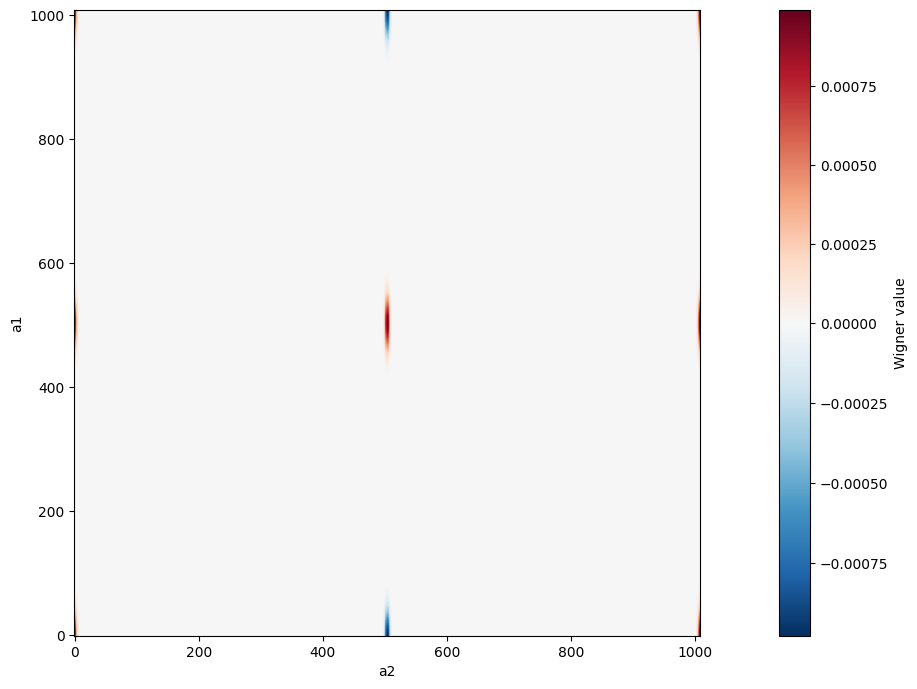

In [ ]:
N = 1009
n = 100

neg1 = np.zeros(n)

psi0 = coherent_state(N, -0.1j, 0.5, 0.5)
W0 = wigner_function(np.outer(psi0, psi0.conj())).real
neg1[0] = np.sum((np.abs(W0)-W0))/2

for i in range(1, n):
    U = diagonalize_floquet_operator(N, 0, 0, 0.4)
    psi = U@psi0
    rho = np.outer(psi, psi.conj())
    W = wigner_function(rho).real  
    neg1[i] = np.sum((np.abs(W) - W))/2
    """if i%10==0:
        plot_WF(W, f"{i}")"""
    psi0 = psi

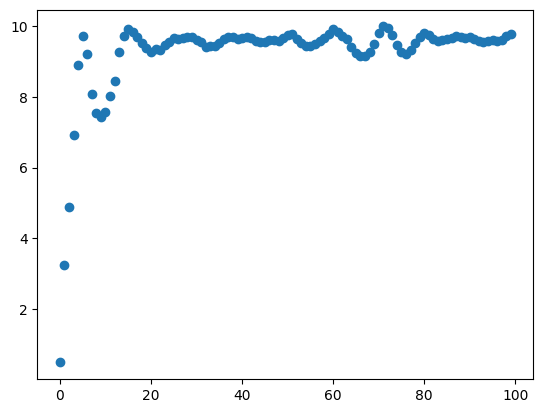

In [5]:
plt.scatter(np.arange(n), neg1)
plt.show()

In [19]:
def system_size_dependence(sizes, kappa, Z = -0.05j):

    neg = np.zeros(len(sizes))
    for i in range(len(sizes)):
        U = diagonalize_floquet_operator(sizes[i], 0, 0, kappa)
        psi0 = coherent_state(sizes[i], Z, 0.5, 0.5)
        psi = time_evol(U, 10, psi0)
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real
        neg[i] = np.sum(np.abs(W) - W)/2
        psi0 = psi

    return neg

In [25]:
sys_sizes = np.array([11, 53, 107, 281, 479, 659, 733, 859, 953, 1009, 1103, 1277, 1321, 1487, 1619, 1783, 1933])

n1 = system_size_dependence(sys_sizes, 0.01)
n2 = system_size_dependence(sys_sizes, 1)
n3 = system_size_dependence(sys_sizes, 6)

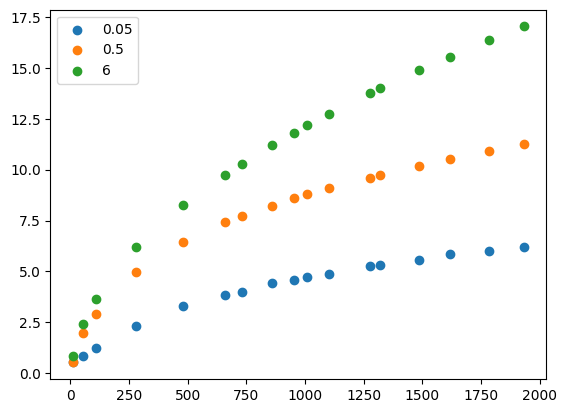

In [28]:
plt.scatter(sys_sizes, system_size_dependence(sys_sizes, 0.05), label = "0.05")
plt.scatter(sys_sizes, system_size_dependence(sys_sizes, 0.5), label = "0.5")
plt.scatter(sys_sizes, n3, label = "6")

plt.legend()
plt.show()

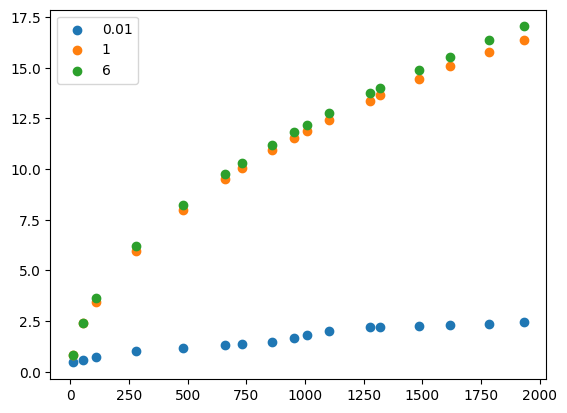

In [26]:
plt.scatter(sys_sizes, n1, label = "0.01")
plt.scatter(sys_sizes, n2, label = "1")
plt.scatter(sys_sizes, n3, label = "6")
plt.legend()
plt.show()

In [6]:
Z = -0.05j

sys_sizes = np.array([11, 53, 107, 281, 479, 659, 733, 859, 953, 1009, 1103, 1277, 1321, 1487, 1619, 1783, 1933])
neg2 = np.zeros(len(sys_sizes))
neg3 = np.zeros(len(sys_sizes))

for i in range(len(sys_sizes)):
    U = diagonalize_floquet_operator(sys_sizes[i], 0, 0, 0.1)
    psi0 = coherent_state(sys_sizes[i], Z, 0.5, 0.5)
    psi = time_evol(U, 50, psi0)
    rho = np.outer(psi, psi.conj())
    W = wigner_function(rho).real
    neg2[i] = np.sum(np.abs(W) - W)/2
    psi0 = psi

for i in range(len(sys_sizes)):
    psi0 = coherent_state(sys_sizes[i], Z, 0.5, 0.5)
    rho = np.outer(psi, psi.conj())
    W = wigner_function(rho).real
    neg3[i] = np.sum(np.abs(W) - W)/2
    psi0 = psi

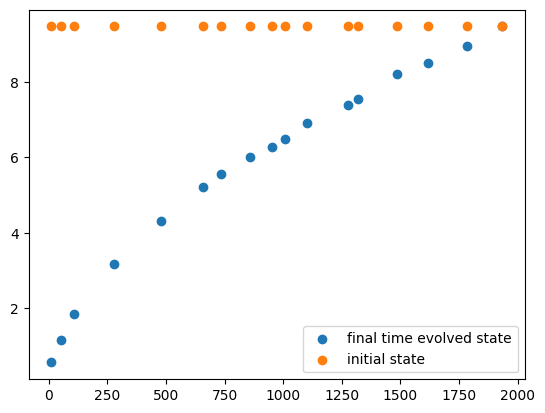

In [8]:
plt.scatter(sys_sizes, neg2, label = "final time evolved state")
plt.scatter(sys_sizes, neg3, label = "initial state")
plt.legend()
plt.show()

In [23]:
# check with coupling constant

#coupling = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.5, 3, 4, 4.5, 5, 6, 7, 8, 9, 10])

coupling = np.linspace(0.1, 6, 50)
neg4 = np.zeros(len(coupling))

for i in range(len(coupling)):
    U = diagonalize_floquet_operator(N, 0, 0, coupling[i])
    psi0 = coherent_state(N, Z, 0.5, 0.5)
    psi = time_evol(U, 10, psi0)
    rho = np.outer(psi, psi.conj())
    W = wigner_function(rho).real
    neg4[i] = np.sum(np.abs(W) - W)/2

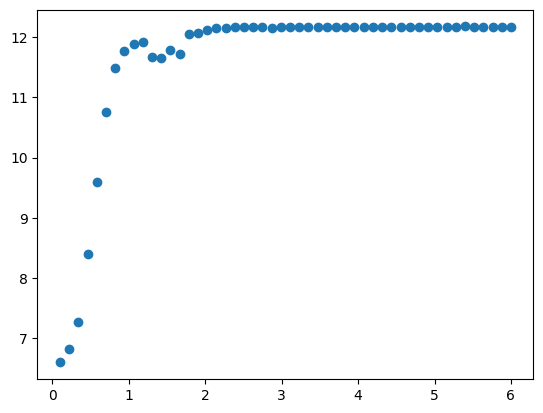

In [24]:
plt.scatter(coupling, neg4)
plt.show()

In [29]:
def time_evol_negativity(ini_state, N, n):

    neg1 = np.zeros(n)

    psi0 = coherent_state(N, -0.1j, 0.5, 0.5)
    W0 = wigner_function(np.outer(psi0, psi0.conj())).real
    neg1[0] = np.sum((np.abs(W0)-W0))/2

    for i in range(1, n):
        U = diagonalize_floquet_operator(N, 0, 0, 0.4)
        psi = U@psi0
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real  
        neg1[i] = np.sum((np.abs(W) - W))/2
        psi0 = psi

    return neg1

In [70]:
random_psi = np.zeros(N, dtype = complex)

random_psi[100:150] = np.random.uniform(-1, 1, 50) + 1j * np.random.uniform(-1, 1, 50)

random_psi /= np.linalg.norm(random_psi)

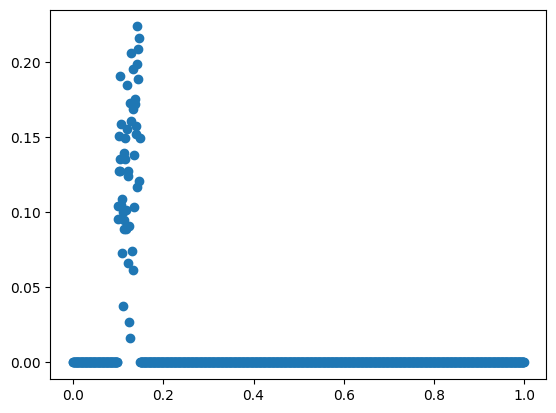

In [71]:
plt.scatter(np.arange(N)/N, np.abs(random_psi))
plt.show()

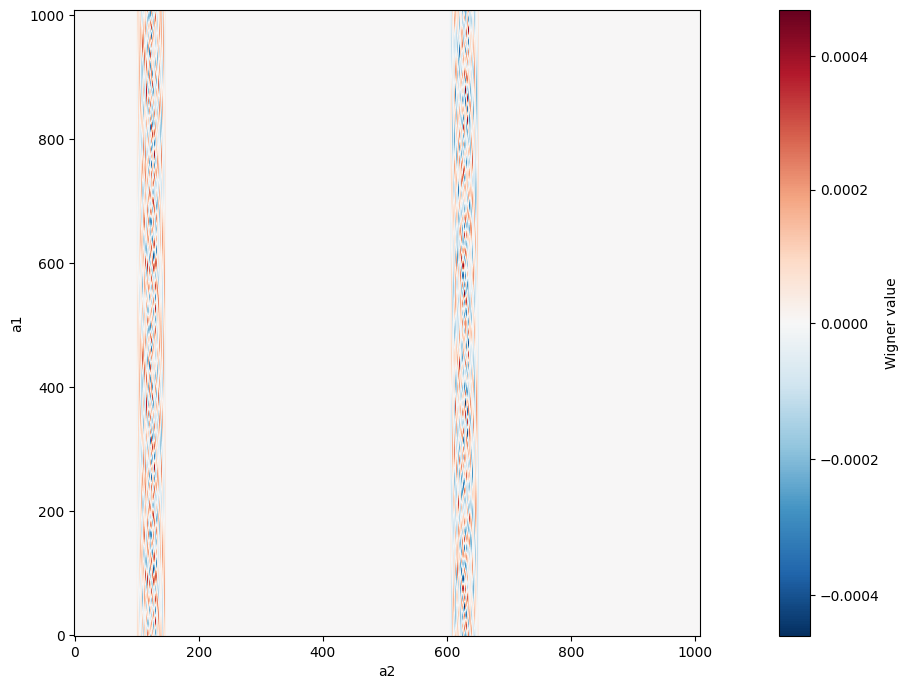

In [66]:
rho = np.outer(random_psi, random_psi.conj())

W = wigner_function(rho).real

plot_WF(W, "")

In [67]:
eta = 0.5 * (np.sum(np.abs(W) - W))

eta

np.float64(3.226310938723607)

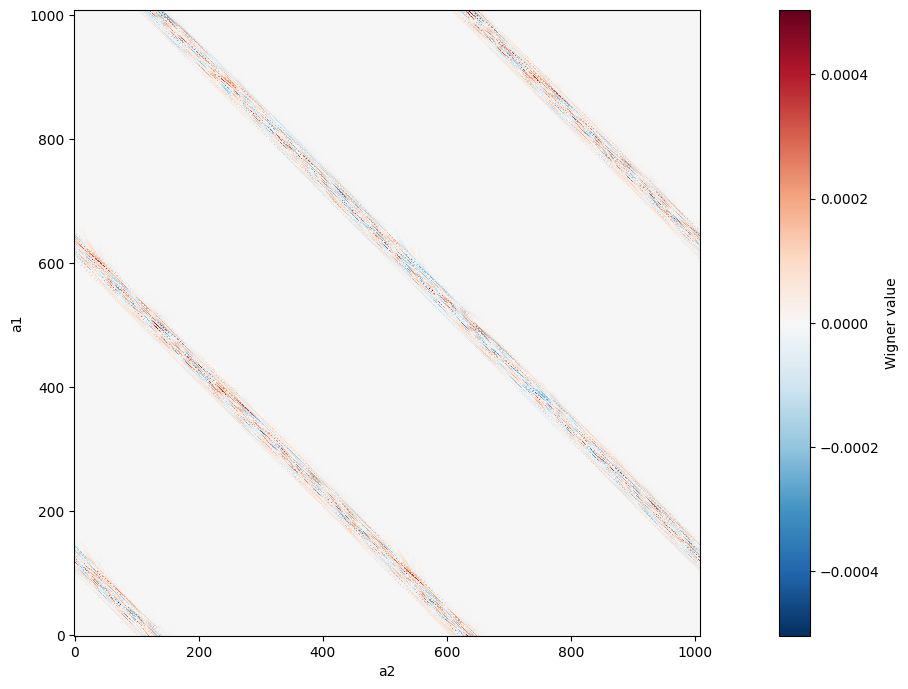

3.9562118682572445


In [72]:
U = diagonalize_floquet_operator(N, 0.2, 0, 0.01)

psi1 = U@random_psi

W1 = wigner_function(np.outer(psi1, psi1.conj())).real

plot_WF(W1, "")

eta = 0.5 * (np.sum(np.abs(W1) - W1))

print(eta)